In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url,sep=r"\s+",skiprows=22,header=None)
X = np.hstack([
    raw_df.values[::2, :],
    raw_df.values[1::2, :2]
])
y = raw_df.values[1::2, 2]


print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (506, 13)
Target Shape  : (506,)


In [3]:
# Proper column names
columns=['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
         'DIS','RAD','TAX','PTRATIO','B','LSTAT']

# Create proper dataframe
data=pd.DataFrame(X,columns=columns)

# Add target column
data['PRICE']=y

# Display dataset
print(data.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (404, 13)
Testing Data Shape  : (102, 13)


In [5]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Data Scaling Completed")

Data Scaling Completed


In [6]:
model = Sequential([ Dense(64, activation='relu',input_shape=(13,) ),Dense(32,activation='relu'), Dense(1)])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])

model.summary()

C:\Users\nites\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
print("Training model... please wait.")

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    verbose=0
)

print("Training Completed")

Training model... please wait.
Training Completed


In [8]:
y_pred = model.predict(X_test).flatten()

print("Prediction Completed")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Prediction Completed


In [9]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Difference (Error)': y_test - y_pred
})
# Absolute Error
comparison_df['Absolute Error'] = np.abs(
    comparison_df['Difference (Error)']
)
print("\nTop 10 Test Set Comparisons")
print(
    comparison_df
    .head(10)
    .round(2)
    .to_string(index=False)
)


Top 10 Test Set Comparisons
 Actual Value  Predicted Value  Difference (Error)  Absolute Error
         23.6        29.670000               -6.07            6.07
         32.4        32.799999               -0.40            0.40
         13.6        21.680000               -8.08            8.08
         22.8        27.940001               -5.14            5.14
         16.1        17.770000               -1.67            1.67
         20.0        20.480000               -0.48            0.48
         17.8        13.370000                4.43            4.43
         14.0        15.440000               -1.44            1.44
         19.6        23.719999               -4.12            4.12
         16.8        16.160000                0.64            0.64


In [10]:
new_data_raw = np.array([[0.1, 10.0,
5.0, 0, 0.4, 6.0, 50, 6.0, 1, 400, 20, 300, 10]])
new_data_scaled = scaler.transform(
    new_data_raw
)
# Predict
prediction = model.predict(
    new_data_scaled
)
print("\nPredicted House Price:")
print(f"{prediction[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

Predicted House Price:
15.63


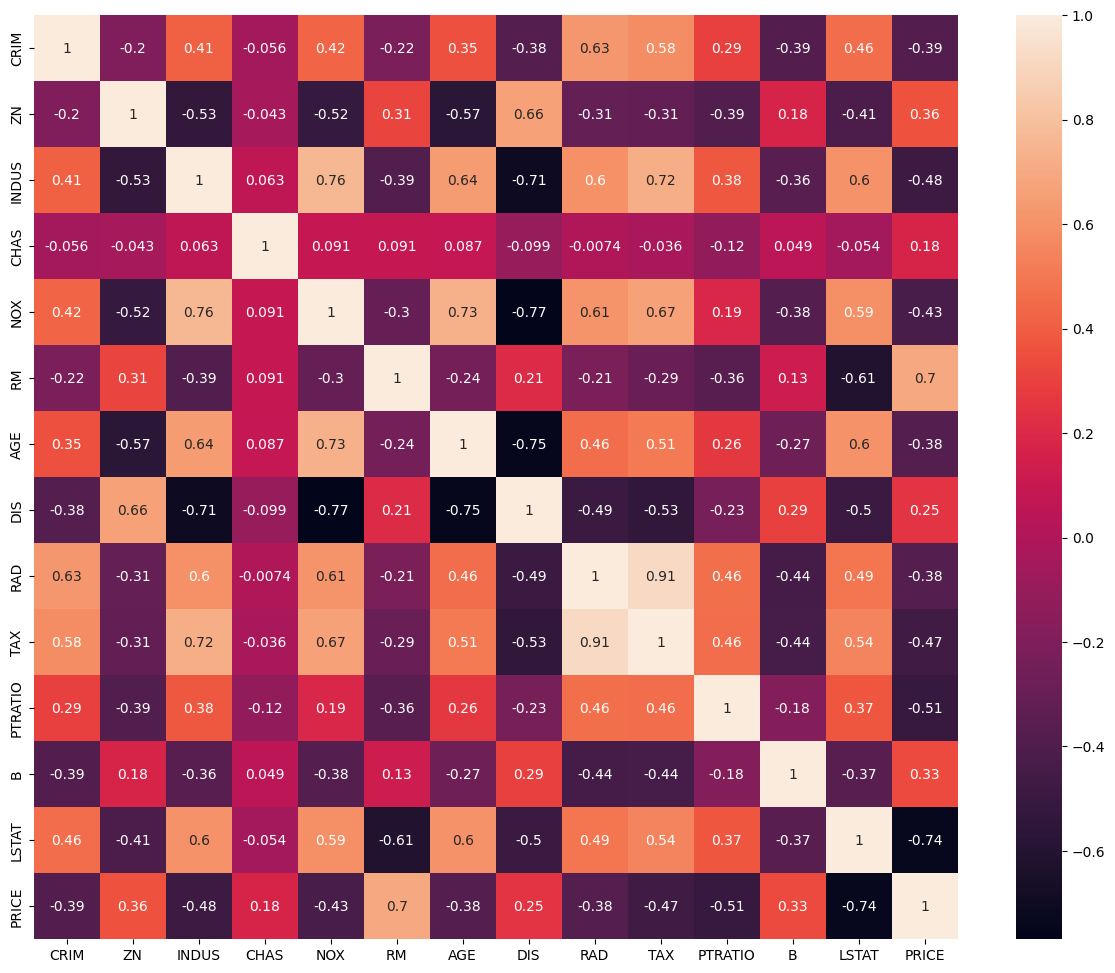

In [11]:
import matplotlib.pyplot as plt
correlation = data.corr()
# correlation.loc['PRICE']

fig,axes = plt.subplots(figsize=(15,12))
sns.heatmap(correlation,square = True,annot = True)
plt.show()

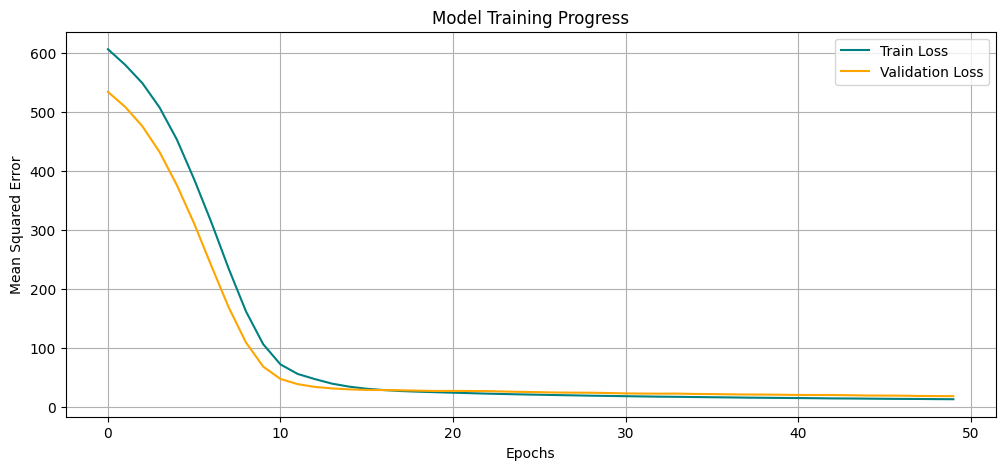

In [12]:
plt.figure(figsize=(12,5))

# Plot 1: Training Loss



plt.plot(
    history.history['loss'],
    label='Train Loss',
    color='teal'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss',
    color='orange'
)

plt.title('Model Training Progress')

plt.xlabel('Epochs')

plt.ylabel('Mean Squared Error')

plt.legend()

plt.grid(True)

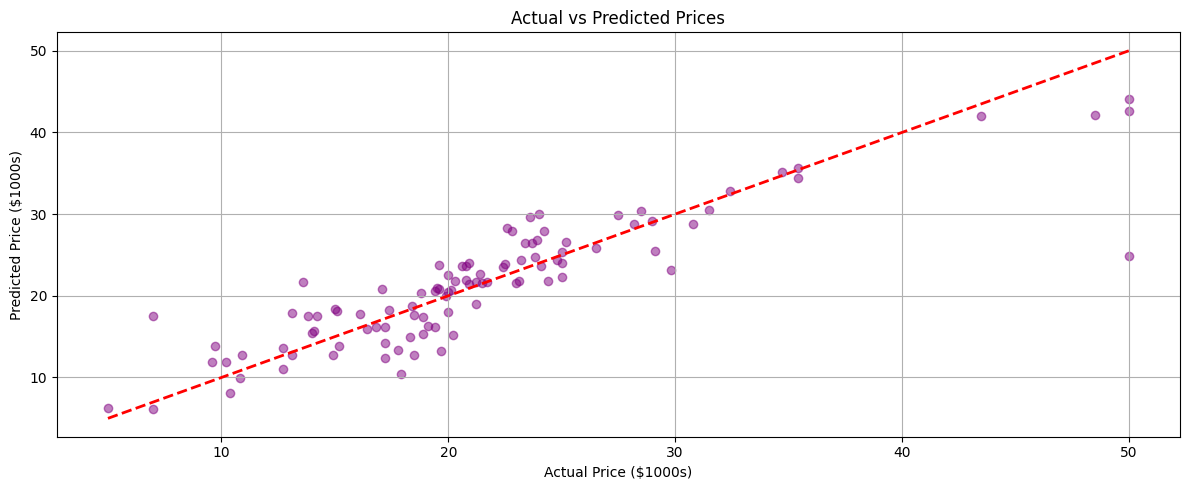

In [13]:

plt.figure(figsize=(12,5))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.5,
    color='purple'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2
)

plt.title('Actual vs Predicted Prices')

plt.xlabel('Actual Price ($1000s)')

plt.ylabel('Predicted Price ($1000s)')

plt.grid(True)

plt.tight_layout()

plt.show()

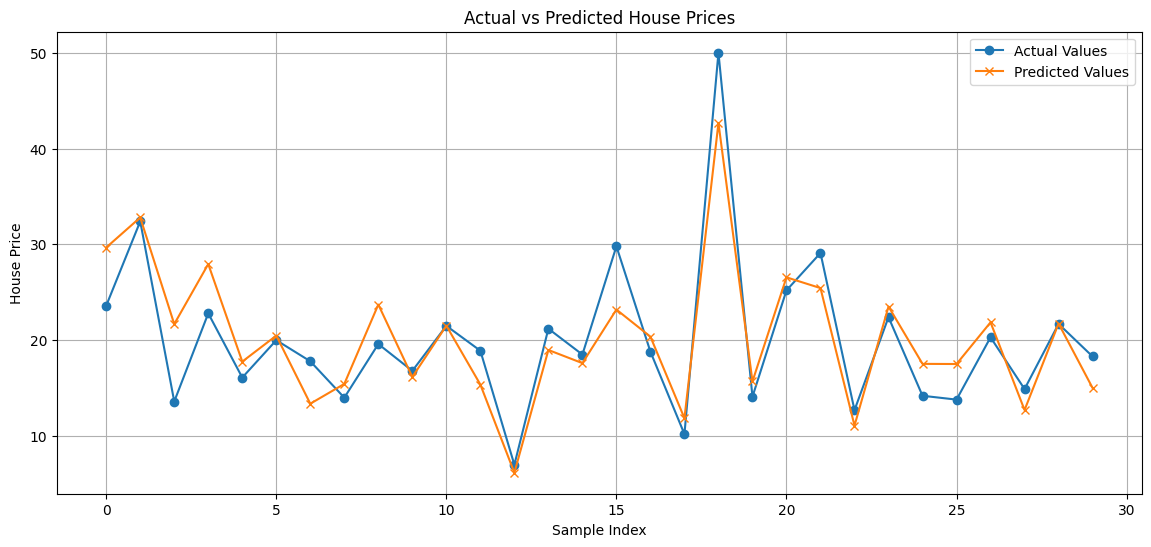

In [14]:
plt.figure(figsize=(14,6))

# Actual Values

plt.plot(
    y_test[:30],
    label='Actual Values',
    marker='o'
)

# Predicted Values

plt.plot(
    y_pred[:30],
    label='Predicted Values',
    marker='x'
)

plt.title("Actual vs Predicted House Prices")

plt.xlabel("Sample Index")

plt.ylabel("House Price")

plt.legend()

plt.grid(True)

plt.show()

In [15]:
# Calculate evaluation metrics

test_mse = mean_squared_error(
    y_test,
    y_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_pred
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    y_test,
    y_pred
)

print("\nModel Evaluation Metrics")

print(f"Mean Squared Error     : {test_mse:.2f}")

print(f"Mean Absolute Error    : {test_mae:.2f}")

print(f"Root Mean Squared Error: {test_rmse:.2f}")

print(f"R2 Score               : {test_r2:.2f}")


Model Evaluation Metrics
Mean Squared Error     : 16.43
Mean Absolute Error    : 2.67
Root Mean Squared Error: 4.05
R2 Score               : 0.78
